In [45]:
import anndata
import os

import importlib.util

# Get the full path to the module
module_path = '/hpc/mydata/mathias.voges/Projects/research/zf-decima/daniodecima-main/src/decima/read_hdf5.py'

# Load the module
spec = importlib.util.spec_from_file_location("read_hdf5", module_path)
read_hdf5 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(read_hdf5)

# src_dir = f'{os.path.dirname(__file__)}/../src/decima/'
# sys.path.append(src_dir)
#from read_hdf5 import HDF5Dataset
# from lightning import LightningModel

In [48]:


# # Parse arguments
# parser = argparse.ArgumentParser()
# parser.add_argument("--name", type=str)
# parser.add_argument("--dir", type=str)
# parser.add_argument("--lr", type=float)
# parser.add_argument("--weight", type=float)
# parser.add_argument("--grad", type=int)
# parser.add_argument("--replicate", type=int, default=0)
# parser.add_argument("--bs", type=int, default=4)
# args = parser.parse_args()



# Get paths
data_dir = "/hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/"
matrix_file = os.path.join(data_dir, "zebrahub_aggregated.h5ad")
h5_file = os.path.join(data_dir, "data.h5")
print(f"Data paths: {matrix_file}, {h5_file}")

# Load data
print("Reading anndata")
#print(os.getcwd())
ad = anndata.read_h5ad(matrix_file)
print(ad)

# Make datasets
# print("Making dataset objects")
train_dataset = read_hdf5.GeneForecastDataset(h5_file=h5_file, ad=ad, key="train", max_seq_shift=5000, augment_mode="random", seed=0, history_length=7, forecast_horizon=3)


Data paths: /hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/zebrahub_aggregated.h5ad, /hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/data.h5
Reading anndata
AnnData object with n_obs × n_vars = 94 × 31767
    obs: 'timepoint', 'cell_type', 'n_cells', 'tissue', 'organ', 'frac_nan', 'total_counts', 'n_genes', 'size_factor'
    var: 'index', 'chrom', 'start', 'end', 'strand', 'gene_type', 'frac_nan', 'mean_counts', 'n_tracks', 'gene_start', 'gene_end', 'gene_length', 'gene_mask_start', 'gene_mask_end', 'frac_N', 'Upstream bases', 'Downstream bases', 'gene', 'fold', 'dataset'
    uns: 'log1p'
    layers: 'counts', 'norm', 'scaled'


In [53]:
print(train_dataset[4])

central_nervous_system
2334
endoderm
2334
lateral_mesoderm
2334


{'static_sequence': tensor([[1., 0., 1.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'expr_series': tensor([[0.4375, 1.9694, 0.0000],
         [0.8659, 0.0000, 0.8026],
         [0.4971, 0.4185, 0.9483],
         [0.6008, 0.4650, 0.8044],
         [1.0552, 0.5083, 0.4126],
         [0.7712, 0.4448, 0.0000],
         [1.1175, 0.4416, 0.0000]]),
 'target': tensor([[1.0845, 0.9925, 0.0000],
         [0.0000, 0.2217, 0.0699],
         [0.2871, 0.2631, 0.2953]])}

In [27]:
# Get paths
# data_dir = "/hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/"
# matrix_file = os.path.join(data_dir, "Supplementary_file_1.h5ad")
# #h5_file = os.path.join(data_dir, "data.h5")
# print(f"Data paths: {matrix_file}, {h5_file}")

# # Load data
# print("Reading anndata")
# #print(os.getcwd())
# ad = anndata.read_h5ad(matrix_file)
# print(ad)

Data paths: /hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/Supplementary_file_1.h5ad, /hpc/mydata/mathias.voges/Projects/research/zf-decima/outputs/grelu/decima/data.h5
Reading anndata
AnnData object with n_obs × n_vars = 8856 × 18457
    obs: 'cell_type', 'tissue', 'organ', 'disease', 'study', 'dataset', 'region', 'subregion', 'celltype_coarse', 'n_cells', 'total_counts', 'n_genes', 'size_factor', 'train_pearson', 'val_pearson', 'test_pearson'
    var: 'chrom', 'start', 'end', 'strand', 'gene_type', 'frac_nan', 'mean_counts', 'n_tracks', 'gene_start', 'gene_end', 'gene_length', 'gene_mask_start', 'gene_mask_end', 'frac_N', 'fold', 'dataset', 'gene_id', 'pearson', 'size_factor_pearson'
    uns: 'log1p'
    layers: 'preds'


In [5]:
print(ad.obs)

,timepoint,cell_type,n_cells,tissue,organ,frac_nan,total_counts,n_genes,size_factor
0,10hpf,central_nervous_system,624,embryo,embryo,0.0,30973962,22647,34764.835938
1,10hpf,endoderm,11,embryo,embryo,0.0,486518,12057,34063.773438
3,10hpf,lateral_mesoderm,109,embryo,embryo,0.0,4617349,17789,35073.730469
5,10hpf,notochord,20,embryo,embryo,0.0,902833,13895,35384.914062
6,10hpf,paraxial_mesoderm,248,embryo,embryo,0.0,11725112,19947,34046.925781
...,...,...,...,...,...,...,...,...,...
93,10dpf,mesenchyme,6960,embryo,embryo,0.0,53170586,24609,34352.222656
94,10dpf,neural_crest,334,embryo,embryo,0.0,2186166,17895,37791.351562
95,10dpf,notochord,13,embryo,embryo,0.0,143197,7867,25035.287109
96,10dpf,paraxial_mesoderm,1245,embryo,embryo,0.0,11645063,20904,31386.361328


In [20]:
cns_cells = ad[ad.obs['cell_type'] == 'central_nervous_system'].copy()
notochord_cells = ad[ad.obs['cell_type'] == 'notochord'].copy()
periderm_cells = ad[ad.obs['cell_type'] == 'periderm'].copy()


In [15]:
notochord_cells.obs['timepoint']

5     10hpf
15    12hpf
25    14hpf
35    16hpf
45    19hpf
55    24hpf
65     2dpf
85     5dpf
95    10dpf
Name: timepoint, dtype: category
Categories (9, object): ['10hpf', '12hpf', '14hpf', '16hpf', ..., '24hpf', '2dpf', '5dpf', '10dpf']

In [4]:
print(cns_cells.var)

,index,chrom,start,end,strand,gene_type,frac_nan,mean_counts,n_tracks,gene_start,gene_end,gene_length,gene_mask_start,gene_mask_end,frac_N,Upstream bases,Downstream bases,gene,fold,dataset
ptpn12,0,4,10000,534288,-,protein_coding,0.0,0.548070,81,17307.0,18211.0,904,516077,516981,0.003645,516077,7307,ptpn12,fold_test,test
CU856344.1,1,4,10000,534288,-,protein_coding,0.0,0.029665,21,48518.0,53370.0,4852,480918,485770,0.003645,480918,38518,CU856344.1,fold_test,test
si:zfos-932h1.3,2,4,10000,534288,-,protein_coding,0.0,0.714176,88,57033.0,64703.0,7670,469585,477255,0.003645,469585,47033,si:zfos-932h1.3,fold_test,test
dusp16,3,4,10000,534288,-,protein_coding,0.0,1.949229,94,107286.0,119689.0,12403,414599,427002,0.003645,414599,97286,dusp16,fold_test,test
gpr19,4,4,10000,534288,-,protein_coding,0.0,1.381391,91,128696.0,133492.0,4796,400796,405592,0.003645,400796,118696,gpr19,fold_test,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chmp1a,31762,25,36967763,37492051,+,protein_coding,0.0,1.407060,93,37435334.0,37441657.0,6323,467571,473894,0.003052,467571,50394,chmp1a,fold_val,val
slc10a3,31763,25,36967763,37492051,+,protein_coding,0.0,2.750704,93,37443193.0,37445449.0,2256,475430,477686,0.003052,475430,46602,slc10a3,fold_val,val
FO834799.1,31764,25,36967763,37492051,+,protein_coding,0.0,0.572847,84,37446860.0,37460976.0,14116,479097,493213,0.003052,479097,31075,FO834799.1,fold_val,val
FO834799.2,31765,25,36967763,37492051,+,lincRNA,0.0,1.839436,92,37466656.0,37476172.0,9516,498893,508409,0.003052,498893,15879,FO834799.2,fold_val,val


In [16]:
import pandas as pd

expression_df = pd.DataFrame(cns_cells[:, ['neurog1']].X.toarray(), 
                            index=cns_cells.obs.index,
                            columns=['neurog1'])




In [17]:
print(expression_df)

,neurog1
0,2.876724
8,4.329853
18,3.568810
28,3.629548
38,2.948632
48,3.497619
58,4.302313
68,3.566427
78,2.938857
88,2.584085


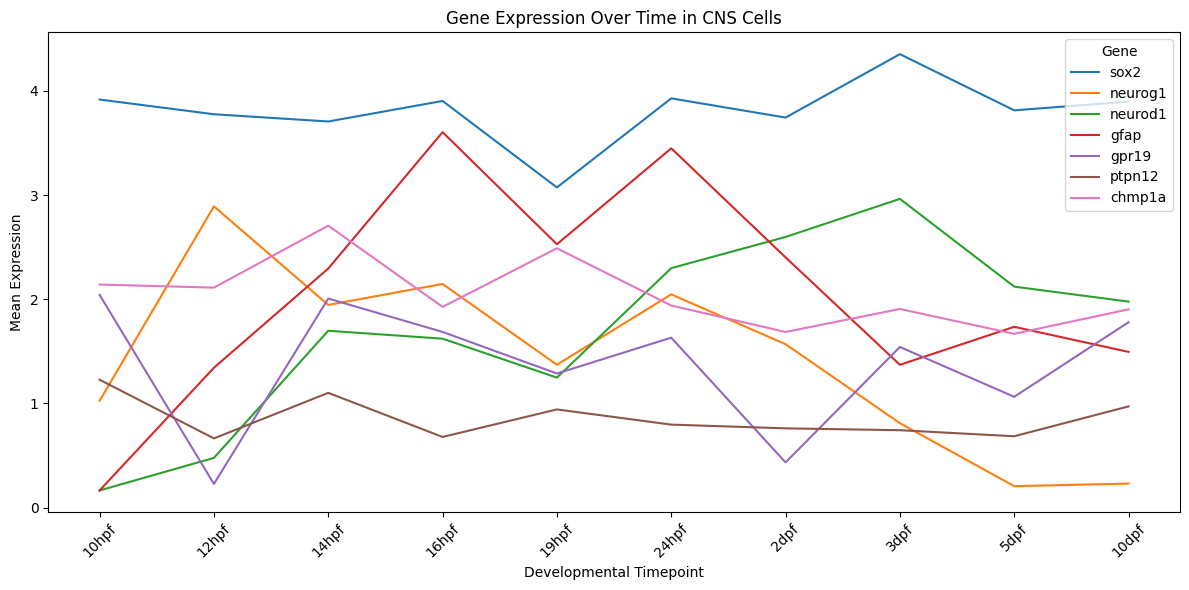

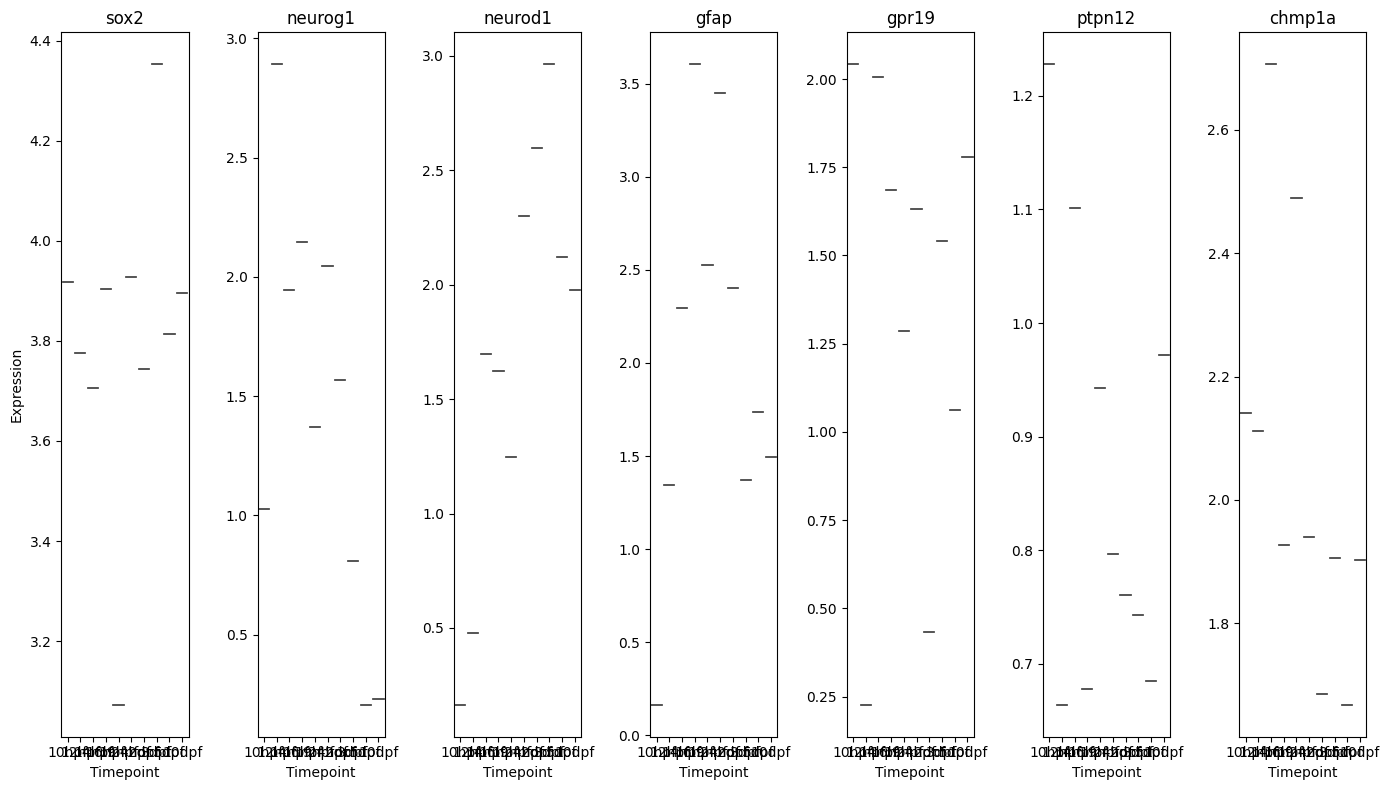

/tmp/ipykernel_2989350/1018679884.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = melted_df.pivot_table(index='Gene', columns='timepoint', values='Expression', aggfunc='mean')


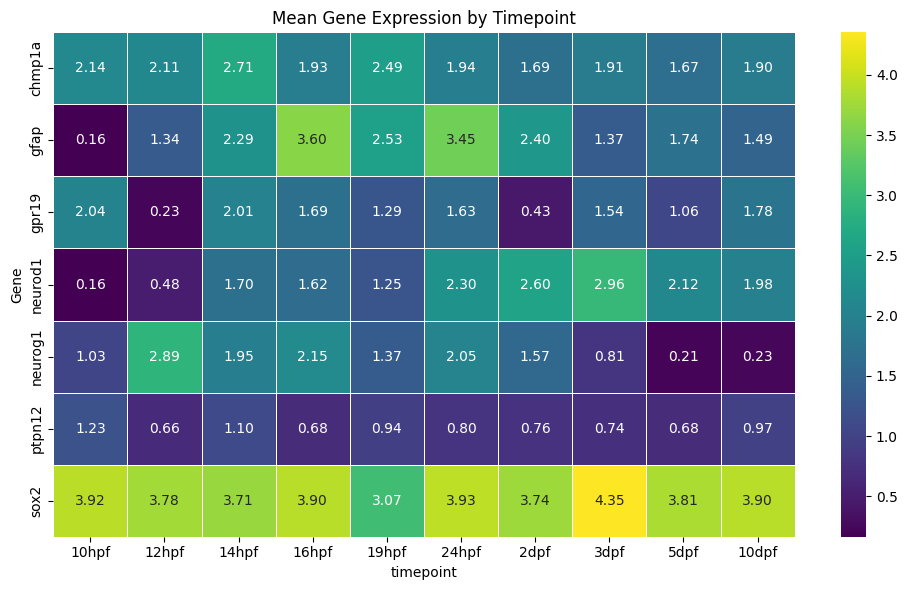

In [21]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming cns_cells is your AnnData object with CNS cells
# and it has a column in .obs called 'timepoint' or similar

# 1. Define the genes you want to plot
genes_of_interest = ['sox2', 'pax6', 'neurog1', 'neurod1', 'gfap', 'gpr19', 'ptpn12', 'chmp1a']  # Replace with your genes

# Make sure all genes exist in the dataset
genes_to_plot = [gene for gene in genes_of_interest if gene in periderm_cells.var_names]
if len(genes_to_plot) < len(genes_of_interest):
    missing_genes = set(genes_of_interest) - set(genes_to_plot)
    print(f"Warning: Some genes not found in dataset: {missing_genes}")

# 2. Extract expression data for these genes
expression_df = pd.DataFrame(periderm_cells[:, genes_to_plot].X.toarray(), 
                            index=periderm_cells.obs.index,
                            columns=genes_to_plot)

# Add timepoint information
expression_df['timepoint'] = periderm_cells.obs['timepoint'].values  # Replace 'timepoint' with your actual column name

# 3. Melt the dataframe for easier plotting
melted_df = pd.melt(expression_df, 
                   id_vars=['timepoint'],
                   value_vars=genes_to_plot,
                   var_name='Gene', 
                   value_name='Expression')

# 4. Create the plot
plt.figure(figsize=(12, 6))

# Option 1: Line plot showing mean expression by timepoint
sns.lineplot(data=melted_df, x='timepoint', y='Expression', hue='Gene', errorbar='se')
plt.title('Gene Expression Over Time in CNS Cells')
plt.xlabel('Developmental Timepoint')
plt.ylabel('Mean Expression')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Option 2: Violin plot to show distribution at each timepoint
plt.figure(figsize=(14, 8))
for i, gene in enumerate(genes_to_plot):
    plt.subplot(1, len(genes_to_plot), i+1)
    sns.violinplot(data=melted_df[melted_df['Gene'] == gene], 
                  x='timepoint', y='Expression')
    plt.title(f'{gene}')
    plt.xlabel('Timepoint')
    if i == 0:
        plt.ylabel('Expression')
    else:
        plt.ylabel('')
plt.tight_layout()
plt.show()

# Option 3: Heatmap of expression over time
pivot_df = melted_df.pivot_table(index='Gene', columns='timepoint', values='Expression', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, cmap='viridis', annot=True, fmt='.2f', linewidths=.5)
plt.title('Mean Gene Expression by Timepoint')
plt.tight_layout()
plt.show()

In [29]:
print(ad.X is not None)


False


In [14]:
import scanpy as sc
sc.pl.violin(ad, keys=["STRADA", "ETV4"], groupby="celltype_coarse")


TypeError: 'NoneType' object is not subscriptable

In [16]:
print(ad.raw)


None
